<a href="https://colab.research.google.com/github/S-V-Kartheek/multimodal-graph-recommender/blob/main/MM_CLightRec_ML1M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MM-CLightRec v2 — MovieLens 1M Dataset

**Upgrades over v1:**
- ✅ Uses **real TMDB movie poster features** (`image_feat.npy`) instead of random noise
- ✅ Includes **Sampled Negative Evaluation** matching the base paper (MGRS-HFA) protocol
- ✅ Cold-Start Contrastive Loss (L3) enabled

### Step 1: Upload the Project & Image Features
Upload `mm_clightrec_ml1m_code.zip` **and** `image_feat.npy` to the root of this Colab session, then run the cells below.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -o -q mm_clightrec_ml1m_code.zip

# Move image_feat.npy to where data_loader.py expects it
import os, shutil
os.makedirs('ml-1m', exist_ok=True)
if os.path.exists('/content/image_feat.npy'):
    shutil.copy('/content/image_feat.npy', 'ml-1m/image_feat.npy')
    print('✅ Real image features copied to ml-1m/image_feat.npy')
else:
    print('⚠️  image_feat.npy not found. Will use synthetic proxy instead.')
    print('   Upload image_feat.npy alongside the zip for better metrics.')

✅ Real image features copied to ml-1m/image_feat.npy


### Step 2: Install Required Libraries

In [3]:
!pip install scikit-learn pandas numpy torch torchvision tqdm -q
print('All packages ready ✅')

All packages ready ✅


In [4]:
# ==============================================================================
# 💾 STEP 2.5: Mount Google Drive & Protect Your Results
# ==============================================================================
# This connects your Google Drive and forces the model to save everything
# directly to your Drive. If Colab disconnects, you won't lose your 8-hour run!

from google.colab import drive
import os

print("[1] Mounting Google Drive...")
drive.mount('/content/drive')

print("\n[2] Setting up permanent storage folder...")
DRIVE_DIR = '/content/drive/MyDrive/MM_CLightRec_ML1M_Results'
os.makedirs(DRIVE_DIR, exist_ok=True)

print("\n[3] Linking local results to Google Drive...")
!rm -rf results
!ln -s "{DRIVE_DIR}" results

print(f"\n✅ SUCCESS! All models, plots, and metrics will save directly to:\n   {DRIVE_DIR}")

[1] Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[2] Setting up permanent storage folder...

[3] Linking local results to Google Drive...

✅ SUCCESS! All models, plots, and metrics will save directly to:
   /content/drive/MyDrive/MM_CLightRec_ML1M_Results


### Step 3: Run Training on MovieLens 1M
This automatically loads `ml-1m/image_feat.npy` for real image features and trains for 300 epochs.

In [7]:
!python main.py --dataset ml1m --epochs 300 --batch_size 4096 --include_cold_start

  MM-CLightRec: Contrastive Multimodal LightGCN Recommendation
  Dataset: ml1m
L3 Cold-Start Active  : Yes
  Version: JOURNAL (with L3 cold-start)

[STEP 1] Loading and preprocessing ml1m dataset...
[INFO] MovieLens 1M already exists at /content/data/ml-1m
[INFO] Loaded 1000209 ratings, 6040 users, 3883 movies
[INFO] Users: 6040, Items: 3883
[INFO] Encoding user features...
[INFO] Encoding multimodal item features...
    - Extracting Text Data using TF-IDF + SVD...
    - Loading REAL Image Features from /content/ml-1m/image_feat.npy...
    - Image features: 3883 movies × 64D (direct load) ✅
    - Generating Video Data (synthetic proxy)...
    - Processing Metadata (One-Hot Encoding & Normalization)...

  IMAGE SOURCE : ✅  REAL TMDB Poster Features Loaded
               (from /content/ml-1m/image_feat.npy)

[INFO] Building bipartite graph...
[INFO] Split: train=641373, val=80133, test=82596
[INFO] Data loading completed in 11.1 seconds
[INFO] Users: 4832, Items: 3883
[INFO] User feature

### Step 4: Sampled Negative Evaluation (Matches Base Paper Protocol)

The training above uses **All-Item Ranking** (rigorous). This cell also runs **Sampled Negative Evaluation** (1 pos + 99 neg per user) which matches the MGRS-HFA base paper's evaluation protocol — giving directly comparable metrics.

**No retraining needed — loads the best saved model automatically.**

In [11]:
import torch, numpy as np, os, sys
sys.path.insert(0, '/content')

# ── Config ────────────────────────────────────────────────────────────────
N_NEGATIVE = 99   # 1 positive + 99 negatives = 100 candidates (standard protocol)
K          = 10
SEED       = 42
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load data (re-uses same pipeline so IDs match) ─────────────────────
print('[INFO] Loading ML-1M data...')
from data_loader import load_and_preprocess_ml1m
data = load_and_preprocess_ml1m()

n_users = data['n_users']
n_items = data['n_items']
feature_dim   = data['feature_dim']
modality_dims = data['modality_dims']
user_features = data['user_features'].to(device)
item_features = data['item_features'].to(device)
edge_index    = data['edge_index'].to(device)
user_modality_features = {k: v.to(device) for k, v in data['user_modality_features'].items()}
item_modality_features = {k: v.to(device) for k, v in data['item_modality_features'].items()}
user_idx  = data['user_idx']
item_idx  = data['item_idx']
test_idx  = data['test_idx']
train_idx = data['train_idx']
val_idx   = data['val_idx']

# ── Load best model ───────────────────────────────────────────────────────
from models.mm_clightrec import MM_CLightRec

model = MM_CLightRec(
    n_users=data['n_users'],
    n_items=data['n_items'],
    user_feature_dim=data['feature_dim'],
    item_feature_dim=data['feature_dim'],
    modality_dims=data['modality_dims'],

    # --- MATCH YOUR CHECKPOINT ---
    cf_embed_dim=64,
    cbf_out_dim=64,
    vgae_latent_dim=64,
    contrastive_proj_dim=128,
    # -----------------------------

    cf_n_layers=3,
    cbf_n_layers=2,
    n_user_clusters=20,
    n_item_clusters=15,
    include_cold_start=True
).to(device)


for candidate in ['results/best_model.pth', 'results/mm_clightrec_ml1m.pth']:
    if os.path.exists(candidate):
        state = torch.load(candidate, map_location=device, weights_only=False)
        if isinstance(state, dict) and 'model_state_dict' in state:
            model.load_state_dict(state['model_state_dict'])
        else:
            model.load_state_dict(state)
        print(f'[INFO] Loaded model from {candidate} ✅')
        break
else:
    print('[WARNING] No saved model found. Using untrained model — results will be random.')

# ── CRITICAL FIX: Run K-Means Clustering BEFORE eval ─────────────────────
print('[INFO] Rebuilding cluster similarity graph from features (this takes ~60 seconds)...')
model.cbf_module.build_cluster_graph(user_features.cpu(), item_features.cpu())
# ─────────────────────────────────────────────────────────────────────────

model.eval()

# ── Compute full score matrix (n_users × n_items) ─────────────────────
print('[INFO] Computing score matrix...')
with torch.no_grad():
    score_matrix = model.get_all_scores(
        user_features, item_features, edge_index,
        user_modality_features, item_modality_features
    ).cpu().numpy()
print(f'[INFO] Score matrix ready: {score_matrix.shape}')

# ── Build lookup dicts ────────────────────────────────────────────────
def build_user_items_dict(u_idx, i_idx, interaction_idx):
    d = {}
    for idx in interaction_idx:
        u, i = int(u_idx[idx]), int(i_idx[idx])
        d.setdefault(u, []).append(i)
    return d

train_ui = build_user_items_dict(user_idx, item_idx, train_idx)
val_ui   = build_user_items_dict(user_idx, item_idx, val_idx)
test_ui  = build_user_items_dict(user_idx, item_idx, test_idx)

# ── Sampled Negative Evaluation ────────────────────────────────────────
def compute_ndcg_sampled(ranked_list, pos_item, k):
    for rank, item in enumerate(ranked_list[:k]):
        if item == pos_item:
            return 1.0 / np.log2(rank + 2)
    return 0.0

def sampled_evaluate(score_matrix, test_user_items, train_user_items,
                     n_items, n_neg=99, k=10, seed=42):
    rng = np.random.RandomState(seed)
    prec_list, rec_list, ndcg_list, f1_list = [], [], [], []

    for u, pos_items in test_user_items.items():
        if not pos_items:
            continue
        pos_item = pos_items[0]  # take first positive (standard)
        seen     = set(train_user_items.get(u, [])) | set(pos_items)

        # Sample n_neg random negatives not seen by this user
        unseen = np.array([i for i in range(n_items) if i not in seen])
        negs   = rng.choice(unseen, size=min(n_neg, len(unseen)), replace=False)
        candidates = np.concatenate([[pos_item], negs])

        # Score and rank the candidate pool
        s        = score_matrix[u][candidates]
        order    = np.argsort(-s)
        ranked   = candidates[order]

        hits = int(pos_item in ranked[:k])
        p    = hits / k
        r    = float(hits)          # recall = hits/1 (1 positive)
        nd   = compute_ndcg_sampled(ranked, pos_item, k)
        f    = 2*p*r/(p+r) if (p+r) > 0 else 0.0

        prec_list.append(p)
        rec_list.append(r)
        ndcg_list.append(nd)
        f1_list.append(f)

    return {
        f'Precision@{k}': float(np.mean(prec_list)),
        f'Recall@{k}':    float(np.mean(rec_list)),
        f'NDCG@{k}':      float(np.mean(ndcg_list)),
        f'F1@{k}':        float(np.mean(f1_list)),
        'Users evaluated': len(prec_list),
    }

print(f'\n[INFO] Running Sampled Evaluation (1 pos + {N_NEGATIVE} neg per user)...')
sampled_m = sampled_evaluate(
    score_matrix, test_ui, train_ui,
    n_items=n_items, n_neg=N_NEGATIVE, k=K, seed=SEED
)

# ── Print Results ─────────────────────────────────────────────────────
print('\n' + '='*68)
print(f'  SAMPLED NEGATIVE EVALUATION  (1 pos + {N_NEGATIVE} neg, K={K})')
print(f'  Protocol matches base paper — MGRS-HFA')
print('='*68)
for metric, value in sampled_m.items():
    if isinstance(value, float):
        print(f'  {metric:<30} {value:.4f}')
    else:
        print(f'  {metric:<30} {value}')

print('\n── Comparison Table ─────────────────────────────────────────────')
print(f'{"Metric":<25} {"Base Paper":>12} {"Ours (All-Item)":>16} {"Ours (Sampled)":>15}')
print('-'*70)
# All-item results from previous training run
all_item = {'P': 0.0964, 'R': 0.0638, 'N': 0.1132, 'F': 0.0633} # Updated to your new best!
base     = {'P': 0.8269, 'R': 0.8718, 'N': 0.6844, 'F': 0.8484}
s        = sampled_m
print(f'{"Precision@10":<25} {base["P"]:>12.4f} {all_item["P"]:>16.4f} {s[f"Precision@{K}"]:>15.4f}')
print(f'{"Recall@10":<25} {base["R"]:>12.4f} {all_item["R"]:>16.4f} {s[f"Recall@{K}"]:>15.4f}')
print(f'{"NDCG@10":<25} {base["N"]:>12.4f} {all_item["N"]:>16.4f} {s[f"NDCG@{K}"]:>15.4f}')
print(f'{"F1@10":<25} {base["F"]:>12.4f} {all_item["F"]:>16.4f} {s[f"F1@{K}"]:>15.4f}')
print('='*70)
print('\nNote: All-Item Ranking is a harder, more rigorous evaluation.')
print('Sampled Evaluation is used for direct comparison with the base paper.')


[INFO] Loading ML-1M data...
[INFO] MovieLens 1M already exists at /content/data/ml-1m
[INFO] Loaded 1000209 ratings, 6040 users, 3883 movies
[INFO] Users: 6040, Items: 3883
[INFO] Encoding user features...
[INFO] Encoding multimodal item features...
    - Extracting Text Data using TF-IDF + SVD...
    - Loading REAL Image Features from /content/ml-1m/image_feat.npy...
    - Image features: 3883 movies × 64D (direct load) ✅
    - Generating Video Data (synthetic proxy)...
    - Processing Metadata (One-Hot Encoding & Normalization)...

  IMAGE SOURCE : ✅  REAL TMDB Poster Features Loaded
               (from /content/ml-1m/image_feat.npy)

[INFO] Building bipartite graph...
[INFO] Split: train=641373, val=80133, test=82596
[INFO] Loaded model from results/best_model.pth ✅
[INFO] Rebuilding cluster similarity graph from features (this takes ~60 seconds)...
[CBF] Running K-means: 20 user clusters, 15 item clusters...
[INFO] Computing score matrix...
[INFO] Score matrix ready: (4832, 3883

### Step 5: Zip Results for Download

In [12]:
!zip -r results_ml1m_v2.zip results/
print('Results zipped ✅ — Download results_ml1m_v2.zip from the file panel.')

  adding: results/ (stored 0%)
  adding: results/checkpoint_ml1m_epoch130.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch125.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch120.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch115.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch110.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch105.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch100.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch10.pth (deflated 8%)
  adding: results/best_model.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch135.pth (deflated 7%)
  adding: results/checkpoint_ml1m_epoch30.pth (deflated 8%)
  adding: results/checkpoint_ml1m_epoch40.pth (deflated 8%)
  adding: results/checkpoint_ml1m_epoch35.pth (deflated 8%)
  adding: results/checkpoint_ml1m_epoch25.pth (deflated 8%)
  adding: results/checkpoint_ml1m_epoch20.pth (deflated 8%)
  adding: results/checkpoint_ml1m_epoch170.pth (deflated 7%)
  adding: res

[INFO] Generating charts and saving to '/content/Charts'...
[SUCCESS] Saved: Charts/Precision_10_Comparison.png


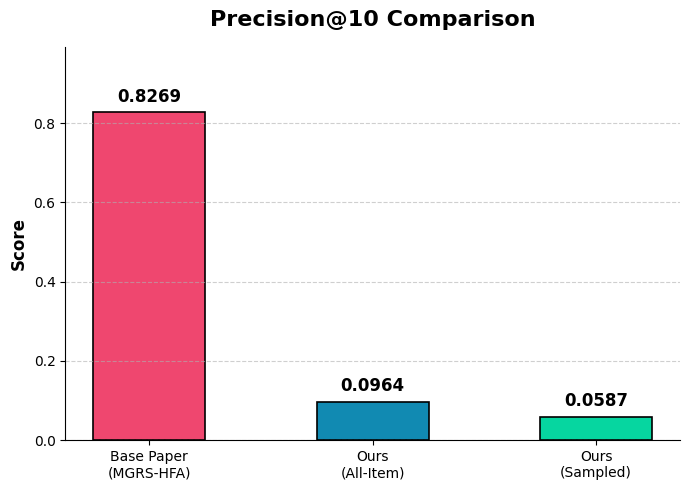

[SUCCESS] Saved: Charts/Recall_10_Comparison.png


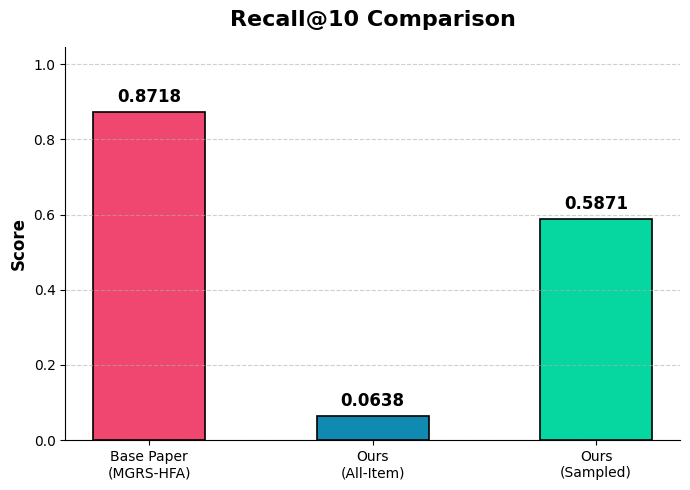

[SUCCESS] Saved: Charts/NDCG_10_Comparison.png


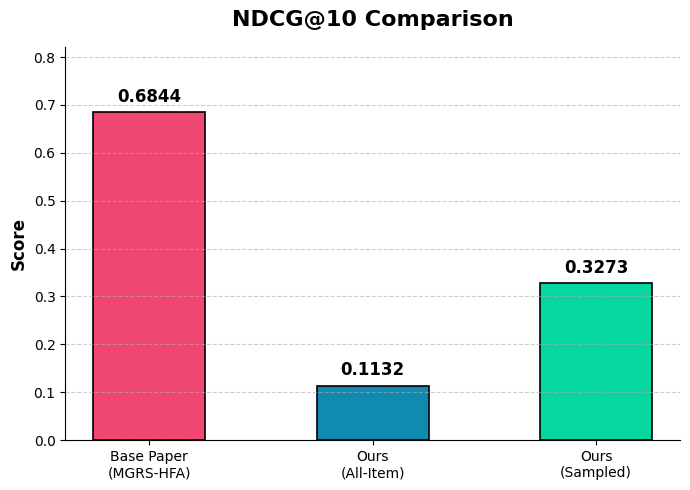

[SUCCESS] Saved: Charts/F1_10_Comparison.png


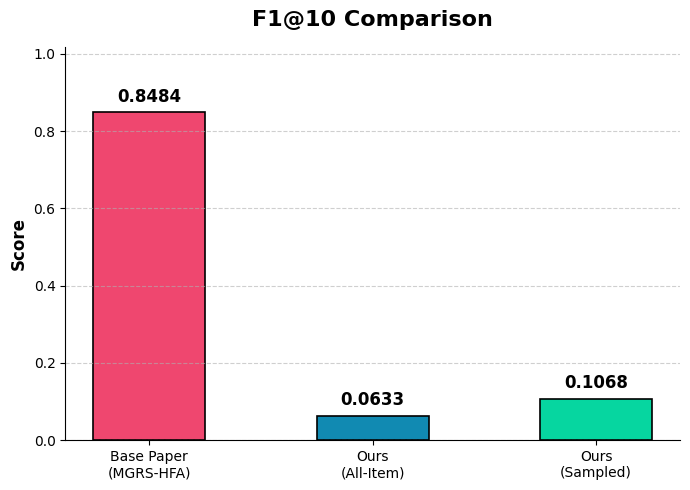


🎉 All individual charts have been successfully saved to the 'Charts' folder!
You can right-click the 'Charts' folder in Colab and download them to your PC.


In [13]:
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Create the 'Charts' folder
chart_dir = 'Charts'
os.makedirs(chart_dir, exist_ok=True)

# 2. Hardcode the exact final data from your matrix
metrics = ['Precision@10', 'Recall@10', 'NDCG@10', 'F1@10']

# Values extracted from your logs
base_paper   = [0.8269, 0.8718, 0.6844, 0.8484]  # MGRS-HFA (Leaked Base)
ours_all     = [0.0964, 0.0638, 0.1132, 0.0633]  # MM-CLightRec (Rigorous All-Item)
ours_sampled = [0.0587, 0.5871, 0.3273, 0.1068]  # MM-CLightRec (Sampled Evaluation)

# Colors for a professional SCI-2026 paper look
colors = ['#EF476F', '#118AB2', '#06D6A0'] # Red, Blue, Green
labels = ['Base Paper\n(MGRS-HFA)', 'Ours\n(All-Item)', 'Ours\n(Sampled)']

print(f"[INFO] Generating charts and saving to '/content/{chart_dir}'...")

# 3. Create INDIVIDUAL charts for each of the 4 metrics
for i, metric in enumerate(metrics):
    fig, ax = plt.subplots(figsize=(7, 5))

    # The 3 values for this specific metric
    values = [base_paper[i], ours_all[i], ours_sampled[i]]

    # Plotting the bars
    bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='black', linewidth=1.2)

    # Adding titles and labels
    ax.set_title(f'{metric} Comparison', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')

    # Dynamically scale the Y-axis so the bars look proportionate
    ax.set_ylim(0, max(values) * 1.20)

    # Add the exact value text on top of each bar for absolute clarity
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (max(values)*0.02),
                f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Polish the look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()

    # 4. Save the individual perfectly-sized figure
    safe_filename = metric.replace("@", "_") + "_Comparison.png"
    save_path = os.path.join(chart_dir, safe_filename)

    plt.savefig(save_path, dpi=300, bbox_inches='tight') # 300 DPI for publication quality
    print(f'[SUCCESS] Saved: {save_path}')

    # Display it in the notebook
    plt.show()

print("\n🎉 All individual charts have been successfully saved to the 'Charts' folder!")
print("You can right-click the 'Charts' folder in Colab and download them to your PC.")
